# 🌲 Forest Cover Type Prediction com Random Forest

**Objetivo**: Classificar 7 tipos de cobertura florestal (Spruce/Fir, Lodgepole Pine, etc.) usando variáveis cartográficas como elevação, inclinação, tipos de solo e áreas selvagens. Dataset oficial Kaggle: [Forest Cover Type Prediction](https://www.kaggle.com/competitions/forest-cover-type-prediction/data).

**Contexto do Problema**  
Prever o tipo de cobertura florestal em áreas de 30x30m na Floresta Nacional Roosevelt (Colorado, EUA) a partir de 54 features (10 quantitativas + 44 binárias). Problema multiclasse com ~15k observações de treino.

# 1. BIBLIOTECAS:

In [25]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 2. DATASET:

In [2]:
train_df = pd.read_csv('train.csv')

In [3]:
# 5 PRIMEIRAS LINHAS DO DATAFRAME:
train_df.head()

,Id,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,1,2596,51,3,258,0,510,221,232,148,...,0,0,0,0,0,0,0,0,0,5
1,2,2590,56,2,212,-6,390,220,235,151,...,0,0,0,0,0,0,0,0,0,5
2,3,2804,139,9,268,65,3180,234,238,135,...,0,0,0,0,0,0,0,0,0,2
3,4,2785,155,18,242,118,3090,238,238,122,...,0,0,0,0,0,0,0,0,0,2
4,5,2595,45,2,153,-1,391,220,234,150,...,0,0,0,0,0,0,0,0,0,5


## 2.1. INFORMAÇÕES DO DATASET:

In [4]:
# SHAPE:
print(f"Shape do dataset: {train_df.shape}")
print(f"   • {train_df.shape[0]} registros")
print(f"   • {train_df.shape[1]} colunas")

Shape do dataset: (15120, 56)
   • 15120 registros
   • 56 colunas


In [5]:
# DTYPES:
print(f"Tipos de dados:")
print(train_df.dtypes)

Tipos de dados:
Id                                    int64
Elevation                             int64
Aspect                                int64
Slope                                 int64
Horizontal_Distance_To_Hydrology      int64
Vertical_Distance_To_Hydrology        int64
Horizontal_Distance_To_Roadways       int64
Hillshade_9am                         int64
Hillshade_Noon                        int64
Hillshade_3pm                         int64
Horizontal_Distance_To_Fire_Points    int64
Wilderness_Area1                      int64
Wilderness_Area2                      int64
Wilderness_Area3                      int64
Wilderness_Area4                      int64
Soil_Type1                            int64
Soil_Type2                            int64
Soil_Type3                            int64
Soil_Type4                            int64
Soil_Type5                            int64
Soil_Type6                            int64
Soil_Type7                            int64
Soil_Type8      

In [6]:
# INFO:
print(f"Informações gerais:")
print(train_df.info())

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15120 entries, 0 to 15119
Data columns (total 56 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Id                                  15120 non-null  int64
 1   Elevation                           15120 non-null  int64
 2   Aspect                              15120 non-null  int64
 3   Slope                               15120 non-null  int64
 4   Horizontal_Distance_To_Hydrology    15120 non-null  int64
 5   Vertical_Distance_To_Hydrology      15120 non-null  int64
 6   Horizontal_Distance_To_Roadways     15120 non-null  int64
 7   Hillshade_9am                       15120 non-null  int64
 8   Hillshade_Noon                      15120 non-null  int64
 9   Hillshade_3pm                       15120 non-null  int64
 10  Horizontal_Distance_To_Fire_Points  15120 non-null  int64
 11  Wilderness_Area1                    15120 non-n

In [7]:
# VALORES NULOS:
print(f"Valores nulos por coluna:")
print(train_df.isnull().sum())

Valores nulos por coluna:
Id                                    0
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10   

# 3. ANÁLISE EXPLORATÓRIA DE DADOS (EDA):

In [8]:
# DESCRIBE:
print(f"Estatísticas descritivas:")
print(train_df.describe())

Estatísticas descritivas:
                Id     Elevation        Aspect         Slope  \
count  15120.00000  15120.000000  15120.000000  15120.000000   
mean    7560.50000   2749.322553    156.676653     16.501587   
std     4364.91237    417.678187    110.085801      8.453927   
min        1.00000   1863.000000      0.000000      0.000000   
25%     3780.75000   2376.000000     65.000000     10.000000   
50%     7560.50000   2752.000000    126.000000     15.000000   
75%    11340.25000   3104.000000    261.000000     22.000000   
max    15120.00000   3849.000000    360.000000     52.000000   

       Horizontal_Distance_To_Hydrology  Vertical_Distance_To_Hydrology  \
count                      15120.000000                    15120.000000   
mean                         227.195701                       51.076521   
std                          210.075296                       61.239406   
min                            0.000000                     -146.000000   
25%                   

## 3.1. HISTOGRAMAS:

In [9]:
# DISTRIBUIÇÃO DAS CLASSES:
train_df['Cover_Type'].value_counts()

Cover_Type
5    2160
2    2160
1    2160
7    2160
3    2160
6    2160
4    2160
Name: count, dtype: int64

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_17620\2135718037.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='Cover_Type', palette='husl')


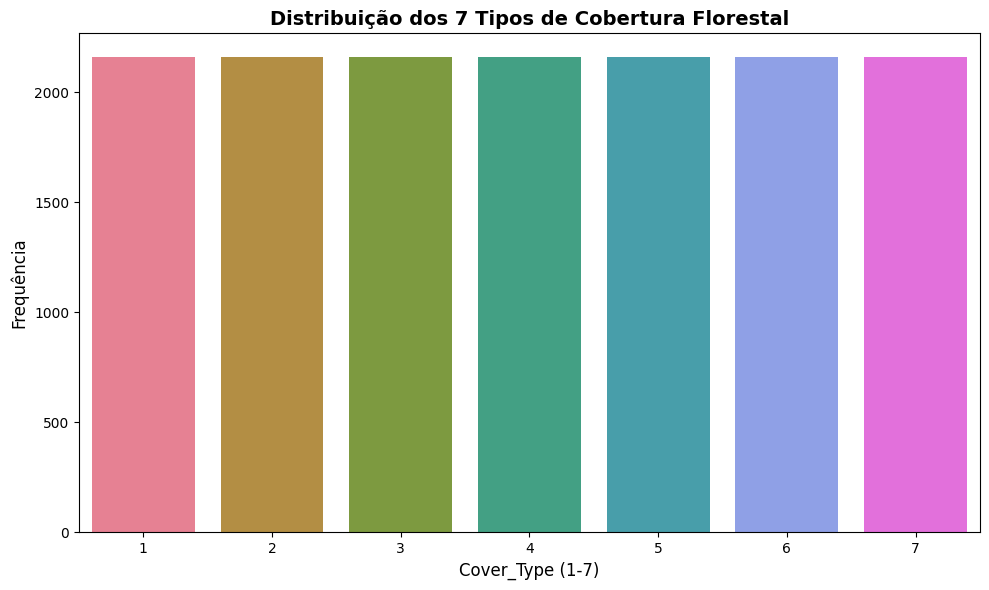

In [10]:
# DISTRIBUIÇÃO DAS CLASSES:
plt.figure(figsize=(10,6))
sns.countplot(data=train_df, x='Cover_Type', palette='husl')
plt.title('Distribuição dos 7 Tipos de Cobertura Florestal', fontsize=14, fontweight='bold')
plt.xlabel('Cover_Type (1-7)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

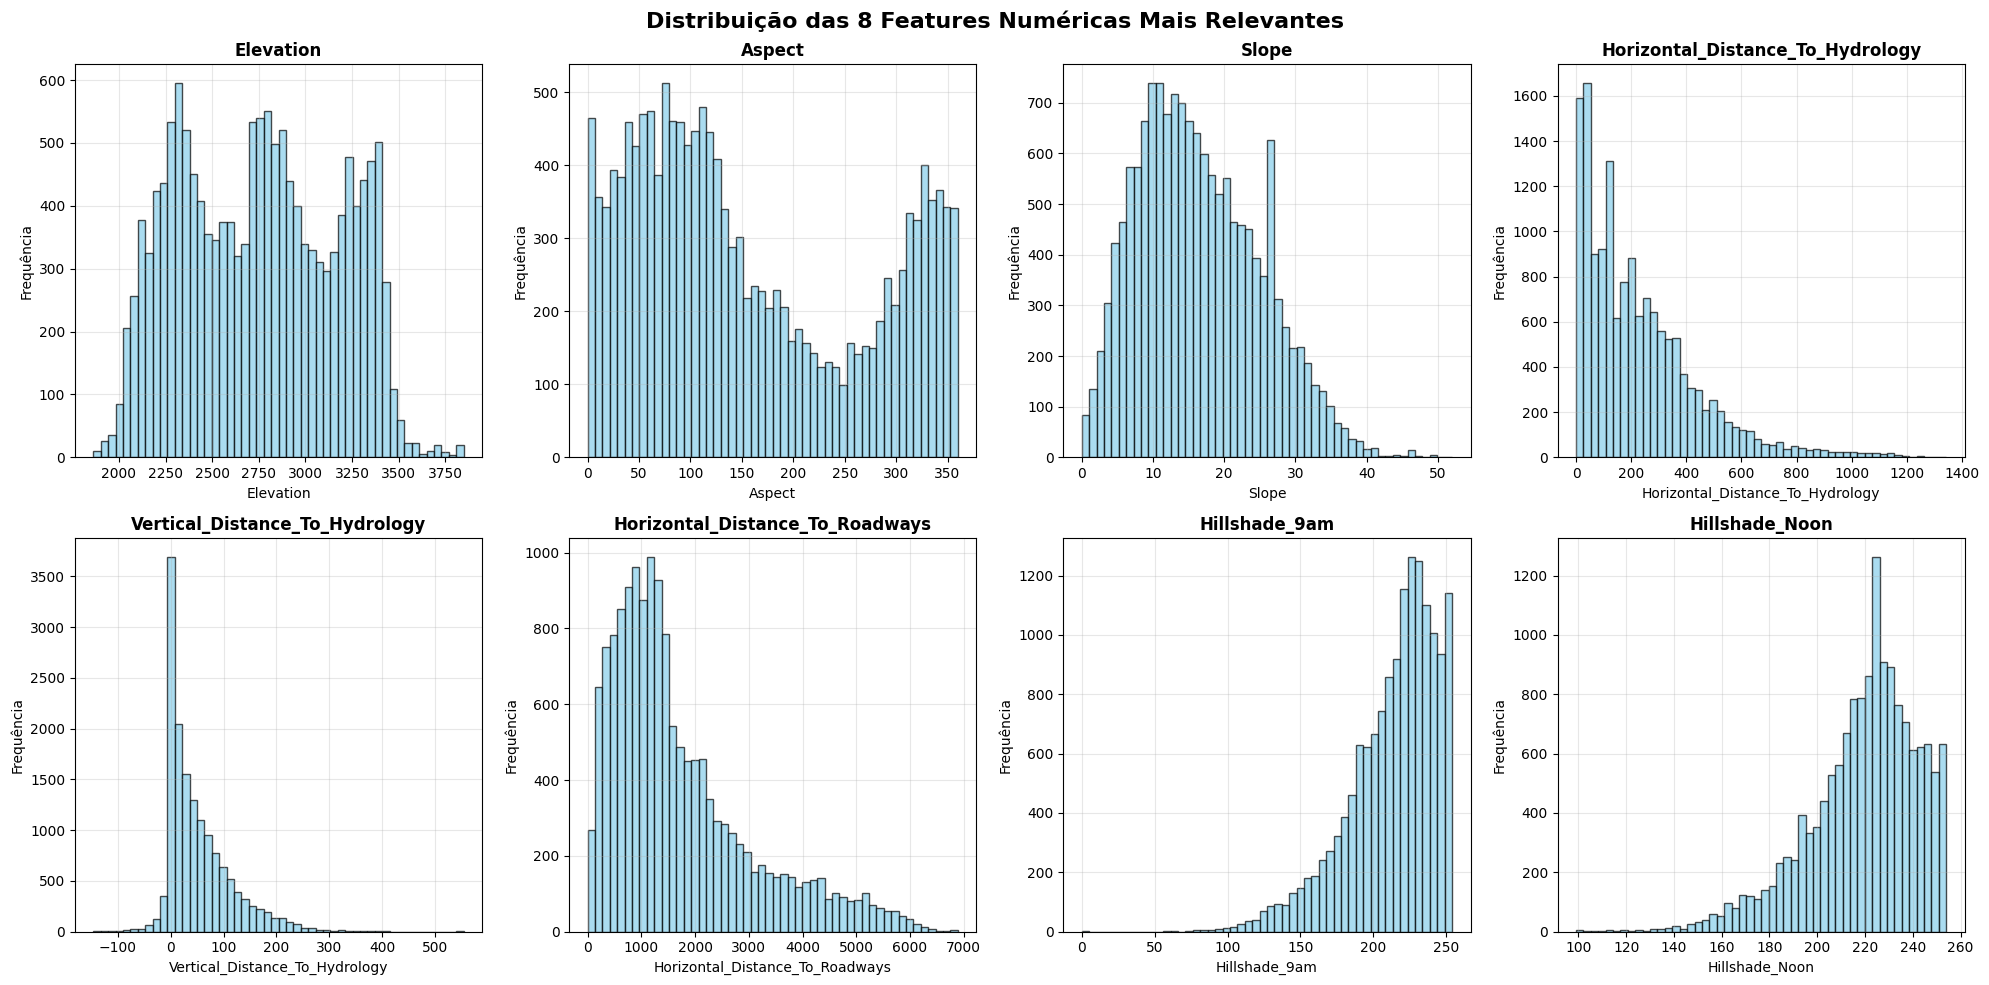

In [11]:
# FEATURES NUMÉRICAS PRINCIPAIS (Top 8 mais relevantes)
num_features = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 
                'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                'Hillshade_9am', 'Hillshade_Noon']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Distribuição das 8 Features Numéricas Mais Relevantes', fontsize=16, fontweight='bold')

for i, feature in enumerate(num_features):
    ax = axes[i//4, i%4]
    train_df[feature].hist(bins=50, ax=ax, alpha=0.7, edgecolor='black', color='skyblue')
    ax.set_title(f'{feature}', fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequência')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 3.2. KDE - KERNEL DENSITY ESTIMATION:

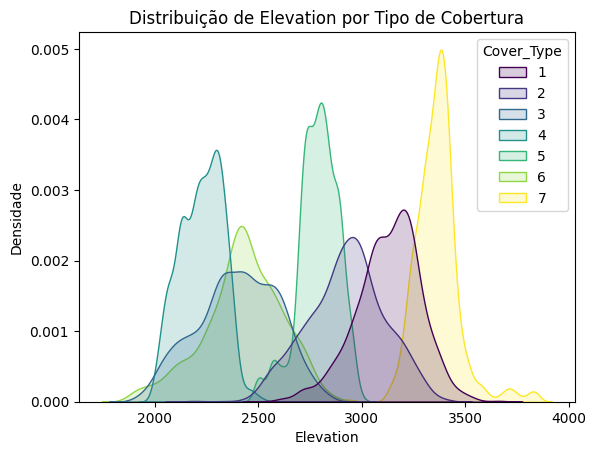

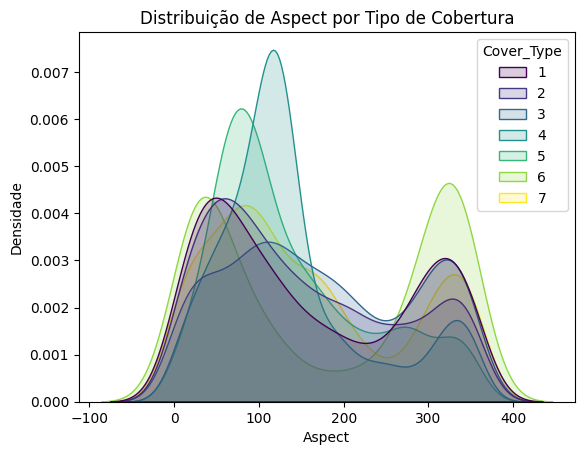

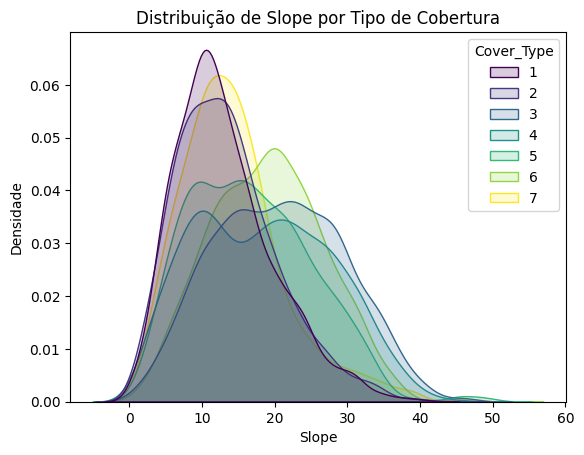

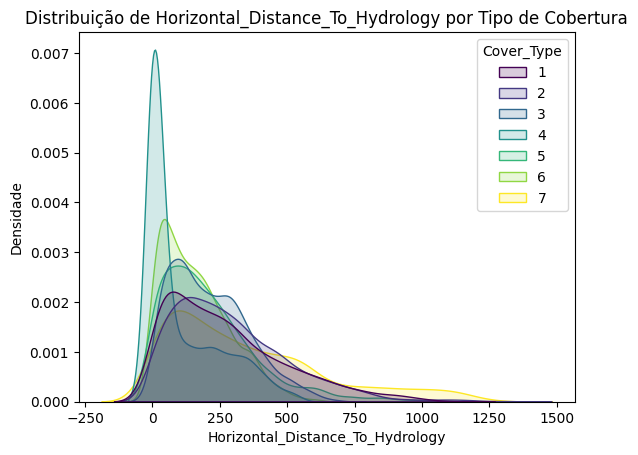

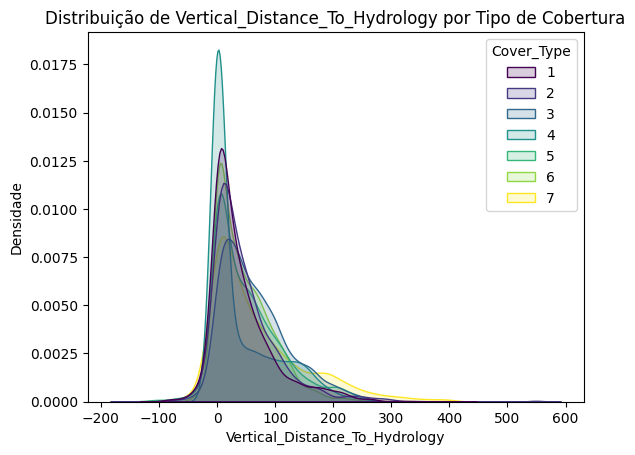

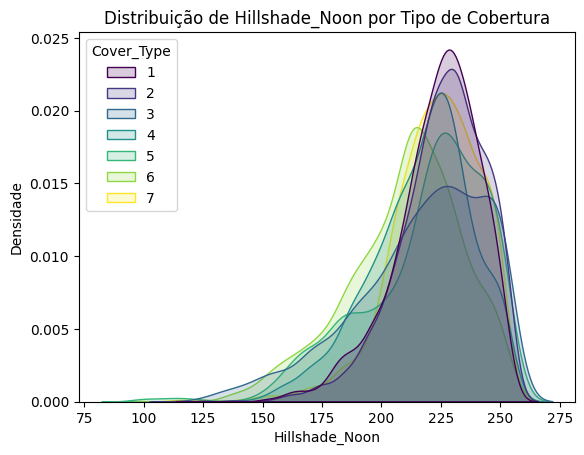

In [12]:
# KDEs por Classe
numeric_cols = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 
                'Vertical_Distance_To_Hydrology', 'Hillshade_Noon']

for col in numeric_cols:
    sns.kdeplot(data=train_df, x=col, hue='Cover_Type', fill=True, common_norm=False, alpha=0.2, palette='viridis')
    plt.title(f'Distribuição de {col} por Tipo de Cobertura')
    plt.xlabel(col)
    plt.ylabel('Densidade')
    plt.show()


### **Principais Observações:**

1. A Feature 'Elevation' parece conseguir diferenciar bem os grande parte dos tipos de cobertura ('Cover_Type' - target), embora os tipos de cobertura 3 e 6 estejam em elevações muito próximas (~ 2400 m)

2. As demais Features não conseguem diferenciar o tipo de cobertura tão bem. Talvez possa ser utilizada para diferenciar apenas um em relação as outras (One-vs-All)

## 3.3. BOXPLOT:

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_17620\4166665985.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y=col, data=train_df, palette='viridis')


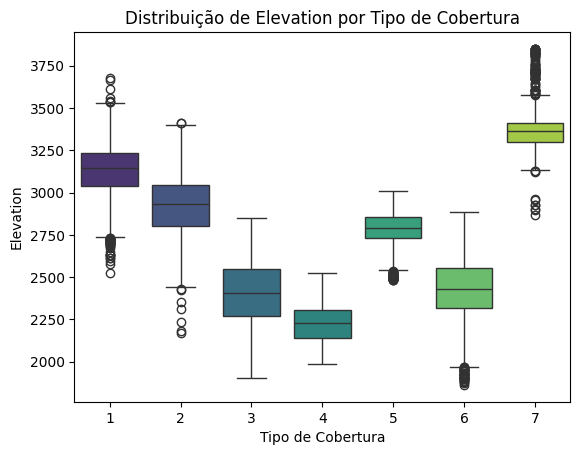

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_17620\4166665985.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y=col, data=train_df, palette='viridis')


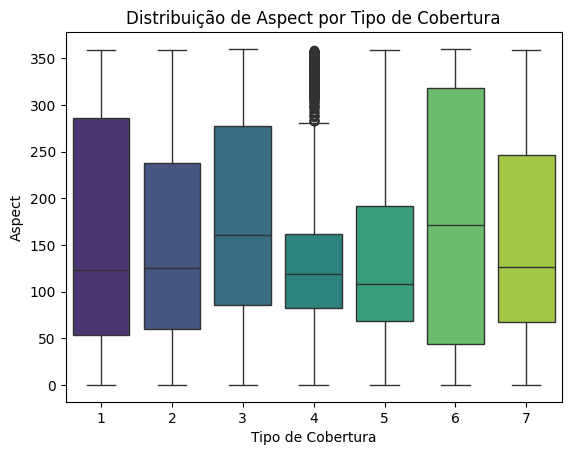

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_17620\4166665985.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y=col, data=train_df, palette='viridis')


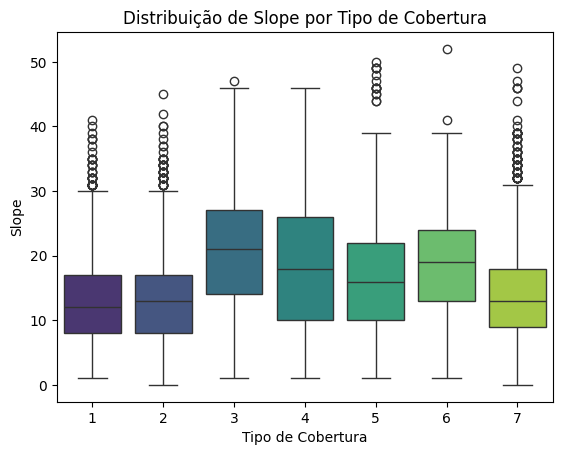

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_17620\4166665985.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y=col, data=train_df, palette='viridis')


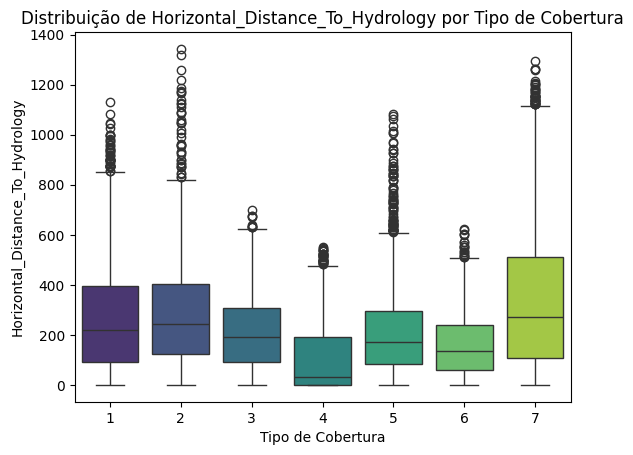

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_17620\4166665985.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y=col, data=train_df, palette='viridis')


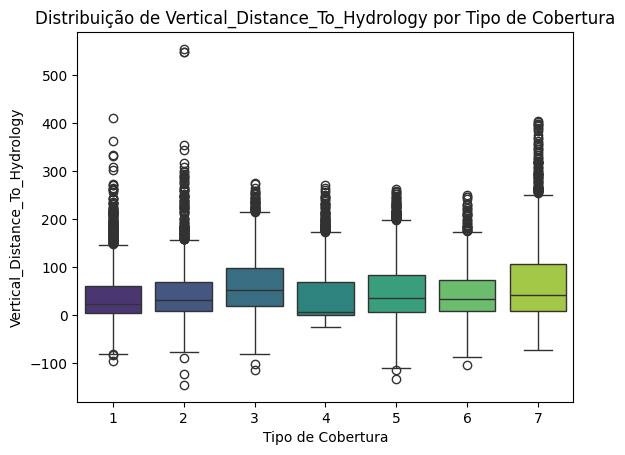

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_17620\4166665985.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y=col, data=train_df, palette='viridis')


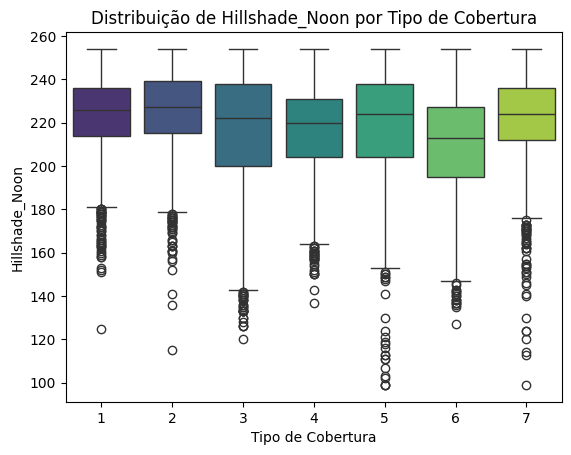

In [13]:
numeric_cols = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 
                'Vertical_Distance_To_Hydrology', 'Hillshade_Noon']

for col in numeric_cols:
    sns.boxplot(x='Cover_Type', y=col, data=train_df, palette='viridis')
    plt.title(f'Distribuição de {col} por Tipo de Cobertura')
    plt.xlabel('Tipo de Cobertura')
    plt.ylabel(col)
    plt.show()

# 4. MODELAGEM - RANDOM FOREST:

## 4.1. PRÉ-PROCESSAMENTO:

In [14]:
# TARGET E FEATURES:
X = train_df.drop('Cover_Type', axis=1)
y = train_df['Cover_Type']

In [15]:
# SPLIT DE TESTE E TREINO ESTRATIFICADO
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # MENTER PROPORÇÃO DE CLASSES
)


In [16]:
# NORMALIZAÇÃO
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4.2. MODELO BASELINE:

In [17]:
# INSTANCIA DO MODELO BASELINE:
rf_baseline = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

In [18]:
# TREINAMENTO DO MODELO BASELINE:
rf_baseline.fit(X_train_scaled, y_train)

RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [19]:
# PREDIÇÕES DO MODELO BASELINE:
y_pred = rf_baseline.predict(X_test_scaled)

### 4.2.1. MÉTRICAS DO MODELO BASELINE:

In [22]:
# ACURÁCIA DO MODELO BASELINE:
print(f"Acurácia (teste): {accuracy_score(y_test, y_pred):.3f}")

Acurácia (teste): 0.868


In [23]:
# CLASSIFICATION REPORT:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.78      0.78      0.78       432
           2       0.81      0.67      0.73       432
           3       0.87      0.82      0.84       432
           4       0.94      0.98      0.96       432
           5       0.89      0.95      0.92       432
           6       0.84      0.90      0.87       432
           7       0.94      0.97      0.95       432

    accuracy                           0.87      3024
   macro avg       0.87      0.87      0.87      3024
weighted avg       0.87      0.87      0.87      3024



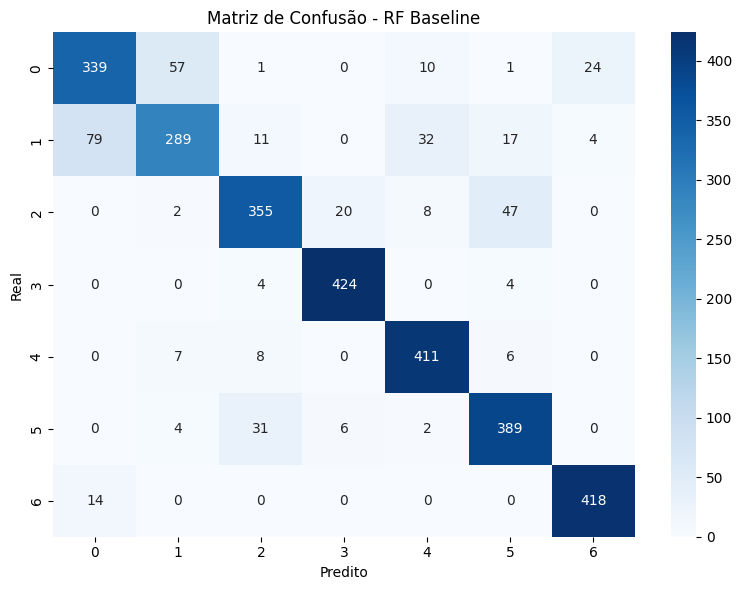

In [24]:
# MATRIZ DE CONFUSÃO:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - RF Baseline')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

### 4.2.1. Métricas do Modelo Baseline (Random Forest)

- **Acurácia no conjunto de teste:** ~0,87  
- **Desempenho por classe:** f1-score variando de ~0,78 a ~0,95, mostrando que o modelo consegue distinguir bem os 7 tipos de cobertura florestal.  
- **Macro / Weighted average:** próximos da acurácia geral, o que reforça que não há classe “esquecida” pelo modelo graças ao dataset balanceado.  

A matriz de confusão mostra uma forte concentração na diagonal principal, com alguns erros entre classes com padrões semelhantes (por exemplo, tipos com faixas de elevação parecidas), o que é esperado para este problema. Esse modelo baseline já é sólido o suficiente para portfólio e servirá como referência para os próximos experimentos de tuning de hiperparâmetros.


# 5. OTIMIZAÇÃO DO MODELO BASELINE:

## 5.1. PRÉ-PROCESSAMENTO:

In [43]:
# OTIMIZAÇÃO DE HIPERPARÂMETROS COM GRID SEARCH
param_grid = {
    'n_estimators': [300, 600],
    'max_depth': [20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# CONFIGURAÇÃO DO GRID SEARCH:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

### Observação:
- Um grid mais amplo foi evitado por causa de um possível alto custo computacional versus ganho esperado, embora pudesse indicar parametros melhores e consequentemente um modelo melhor.

In [44]:
# TREINAMENTO DO GRID SEARCH:
grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [20, None],
                         'max_features': ['sqrt'], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [300, 600]},
             scoring='accuracy', verbose=2)

In [46]:
# RESULTADOS DO GRID SEARCH:
print("Melhor acurácia média (CV):", grid_search.best_score_)
print("Melhores hiperparâmetros:", grid_search.best_params_)

Melhor acurácia média (CV): 0.8667331969019368
Melhores hiperparâmetros: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 600}


## 5.2. MODELO OTIMIZADO:

In [47]:
# AVALIAÇÃO DO MODELO OTIMIZADO:
best_rf = grid_search.best_estimator_

# PREDIÇÕES DO MODELO OTIMIZADO:
y_pred_best = best_rf.predict(X_test_scaled)

## 5.2.1. MÉTRICAS DO MODELO OTIMIZADO:

In [48]:
# ACURÁCIA DO MODELO OTIMIZADO:
print(f"Acurácia (teste) - modelo otimizado: {accuracy_score(y_test, y_pred_best):.3f}")

Acurácia (teste) - modelo otimizado: 0.867


In [49]:
# CLASSIFICATION REPORT DO MODELO OTIMIZADO:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           1       0.78      0.78      0.78       432
           2       0.80      0.66      0.73       432
           3       0.87      0.82      0.84       432
           4       0.94      0.98      0.96       432
           5       0.89      0.95      0.92       432
           6       0.84      0.90      0.87       432
           7       0.94      0.97      0.95       432

    accuracy                           0.87      3024
   macro avg       0.87      0.87      0.86      3024
weighted avg       0.87      0.87      0.86      3024



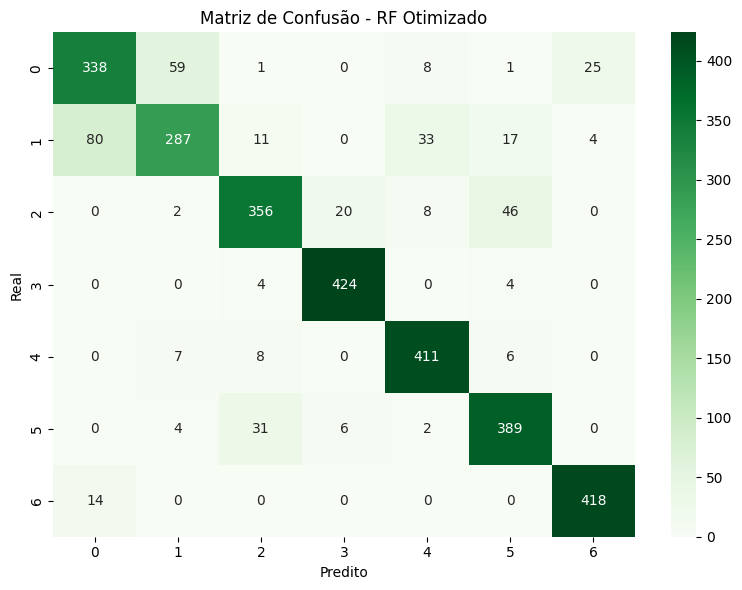

In [50]:
# MATRIZ DE CONFUSÃO DO MODELO OTIMIZADO:
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8,6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão - RF Otimizado')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

### 5.2.2. IMPORTÂNCIA DAS FEATURES NO MODELO OTIMIZADO:

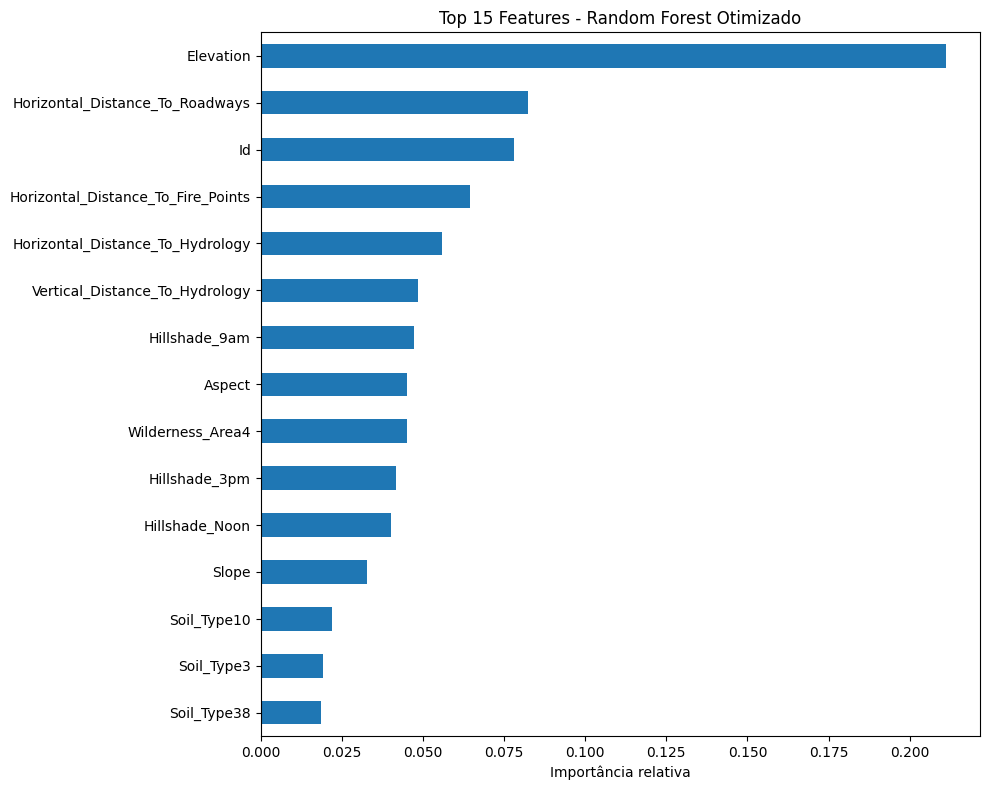

In [51]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,8))
importances.head(15).plot(kind='barh')
plt.title('Top 15 Features - Random Forest Otimizado')
plt.xlabel('Importância relativa')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#### A figura de importância das features mostra que poucas variáveis explicam grande parte da capacidade preditiva do Random Forest otimizado:

- **Elevation** aparece como a feature mais importante do modelo, reforçando a análise dos KDEs e boxplots, onde diferenças de altitude já indicavam boa separação entre os tipos de cobertura florestal.  
- As variáveis de distância (`Horizontal_Distance_To_Hydrology`, `Vertical_Distance_To_Hydrology`, `Horizontal_Distance_To_Roadways`) e de iluminação (`Hillshade_9am`, `Hillshade_Noon`) também apresentam alta relevância, pois ajudam a distinguir florestas em vales, encostas e áreas mais expostas.  